## Loading the base data

In [3]:
import requests
import pandas as pd

url_prefix = 'https://raw.githubusercontent.com/DataTalksClub/llm-zoomcamp/main/03-evaluation/'
docs_url = url_prefix + 'search_evaluation/documents-with-ids.json'
documents = requests.get(docs_url).json()

ground_truth_url = url_prefix + 'search_evaluation/ground-truth-data.csv'
df_ground_truth = pd.read_csv(ground_truth_url)
ground_truth = df_ground_truth.to_dict(orient='records')

In [64]:
result = next((doc for doc in documents if doc['id'] == '5170565b'), {})

result

{'text': 'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
 'section': 'General course-related questions',
 'question': 'What if I miss a session?',
 'course': 'machine-learning-zoomcamp',
 'id': '5170565b'}

In [65]:
questions = [q['question'] for q in ground_truth if q['document'] == '5170565b']

question = questions[0]

question

'Are sessions recorded if I miss one?'

In [66]:
expected_result = next((doc for doc in documents if doc['id'] == '5170565b'), {})

expected_result['text']

'Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.'

### Answer from the RAG

In [67]:
from rag.pipeline import RAGPipeline

rag = RAGPipeline()

rag_result = rag.ask(question=question, search_engine="qdrant")

rag_result

'Yes, sessions are recorded if you miss one. You can view the recordings later, and you also have the option to ask questions in advance for office hours, which will be covered during the live stream.'

### Test Cosine Similarity Evaluation for 1 question and answer

In [68]:
answer_orig = expected_result['text']
answer_llm = rag_result

answer_orig, answer_llm

('Everything is recorded, so you won’t miss anything. You will be able to ask your questions for office hours in advance and we will cover them during the live stream. Also, you can always ask questions in Slack.',
 'Yes, sessions are recorded if you miss one. You can view the recordings later, and you also have the option to ask questions in advance for office hours, which will be covered during the live stream.')

In [69]:
import numpy as np
from rag.data.vector_store import VectorStoreLoader

vsl = VectorStoreLoader()

embedding_model = vsl.get_embedding_model()

# already in numpy array, no need to convert
orig_vector = list(embedding_model.embed(answer_orig))[0]
llm_vector = list(embedding_model.embed(answer_llm))[0]

dot_product = llm_vector.dot(orig_vector)

# 0 completely different, 1 completely the same
print(f"Dot Product/Cosine Similarity is {dot_product}")

Dot Product/Cosine Similarity is 0.8956156349182196


### Scale Cosine Similarity to all the answers

In [ ]:
ground_truth[0]

{'question': 'When does the course begin?',
 'course': 'data-engineering-zoomcamp',
 'document': 'c02e79ef'}

In [76]:
answers = {}

In [ ]:
from tqdm.auto import tqdm

from rag.pipeline import RAGPipeline
from rag.models.course import Course

rag = RAGPipeline()

for i, rec in enumerate(tqdm(ground_truth, desc="Processing ground truth")):

    # if already answered, skip
    if i in answers:
        continue

    # get course filter from enum
    course = rec['course']
    try:
        course_enum = Course.from_string(course)
    except Exception as e:
        print(f"Unknown course: {course}")
        raise e

    # get the answer from the LLM
    answer_llm = rag.ask(question=rec['question'], search_engine="qdrant", course_filter=course_enum)

    doc_id = rec['document']
    original_doc = next((doc for doc in documents if doc['id'] == doc_id), {})
    answer_orig = original_doc['text']

    answers[i] = {'question': rec['question'], 'answer_orig': answer_orig, 'answer_llm': answer_llm, 'document': doc_id, 'course': course}

answers


Processing ground truth:   0%|          | 0/4627 [00:00<?, ?it/s]

{0: {'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'answer_llm': 'The course begins on 15th January 2024 at 17:00.',
  'document': 'c02e79ef',
  'course': 'data-engineering-zoomcamp'},
 1: {'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course T

In [99]:
answers

{'0': {'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'answer_llm': 'The course begins on 15th January 2024 at 17:00.',
  'document': 'c02e79ef',
  'course': 'data-engineering-zoomcamp'},
 '1': {'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the cour

In [ ]:
import json

# write answers to json
with open('answers-gpt4o.json', 'w') as f:
    json.dump(answers, f)

### Save ML Zoomcamp answers for assesment

In [ ]:
with open('answers-gpt4o.json', 'r') as f:
    answers = json.load(f)

# workaround to add answers not to spend money to regenerate addition of questions
results_gpt4o = [None] * len(ground_truth)

for i, val in answers.items():
    i = int(i)
    results_gpt4o[i] = val.copy()
    results_gpt4o[i].update(ground_truth[i])

results_gpt4o

[{'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'answer_llm': 'The course begins on 15th January 2024 at 17:00.',
  'document': 'c02e79ef',
  'course': 'data-engineering-zoomcamp',
  'question': 'When does the course begin?'},
 {'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course sta

In [114]:
import pandas as pd

df = pd.DataFrame(results_gpt4o)

ml_df = df[df['course'] == 'machine-learning-zoomcamp']

ml_df.sample(n=5).to_dict(orient='records')

[{'answer_orig': 'Q: “In lesson 2.8 why is y_pred different from y? After all, we trained X_train to get the weights that when multiplied by X_train should give exactly y, or?”\nA: linear regression is a pretty simple model, it neither can nor should fit 100% (nor any other model, as this would be the sign of overfitting). This picture might illustrate some intuition behind this, imagine X is a single feature:\nAs our model is linear, how would you draw a line to fit all the "dots"?\nYou could "fit" all the "dots" on this pic using something like scipy.optimize.curve_fit (non-linear least squares) if you wanted to, but imagine how it would perform on previously unseen data.\nAdded by Andrii Larkin',
  'answer_llm': 'A sign that indicates a model has overfitted the training data is when larger "C" values are used in models like Support Vector Machines (SVM) and logistic regression. These larger "C" values reduce the regularization effect, allowing the model to fit the training data more

In [116]:
!mkdir data

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [117]:
ml_df.to_csv('data/ml_zoomcamp_results_gpt4o.csv', index=False)

### Try to speed up generation (with GPT 3.5)

In [1]:
from tqdm.auto import tqdm

from concurrent.futures import ThreadPoolExecutor

from rag.pipeline import RAGPipeline
from rag.models.course import Course

pool = ThreadPoolExecutor(max_workers=1)

def map_progress(pool, seq, f):
    """
    Map a function over a sequence and return a list of results.
    Show progress bar.

    Args:
        pool (ThreadPoolExecutor): Thread pool executor
        seq (list): Sequence to process
        f (function): Function to apply to each element of the sequence

    Returns:
        list: List of results
    """
    results = []

    with tqdm(total=len(seq), desc="Processing") as progress:
        futures = []

        for el in seq:
            future = pool.submit(f, el)
            future.add_done_callback(lambda p: progress.update())
            futures.append(future)

        for future in futures:
            result = future.result()
            results.append(result)

    return results

def process_record(rec, rag = RAGPipeline(openai_model="gpt-3.5-turbo")):

    # get course filter from enum
    course = rec['course']
    try:
        course_enum = Course.from_string(course)
    except Exception as e:
        print(f"Unknown course: {course}")
        raise e

    # get the answer from the LLM
    answer_llm = rag.ask(question=rec['question'], search_engine="qdrant", course_filter=course_enum)

    doc_id = rec['document']
    original_doc = next((doc for doc in documents if doc['id'] == doc_id), {})
    answer_orig = original_doc['text']

    return {'question': rec['question'], 'answer_orig': answer_orig, 'answer_llm': answer_llm, 'document': doc_id, 'course': course}

In [137]:
result = process_record(ground_truth[0])

result

{'question': 'When does the course begin?',
 'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
 'answer_llm': 'The course will begin on 15th Jan 2024 at 17h00.',
 'document': 'c02e79ef',
 'course': 'data-engineering-zoomcamp'}

In [4]:
results_gpt35 = map_progress(pool, ground_truth, process_record)

results_gpt35

Processing:   0%|          | 0/4627 [00:00<?, ?it/s]

[{'question': 'When does the course begin?',
  'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works from Desktop only).\nRegister before the course starts using this link.\nJoin the course Telegram channel with announcements.\nDon’t forget to register in DataTalks.Club's Slack and join the channel.",
  'answer_llm': 'The course will begin on 15th Jan 2024 at 17h00.',
  'document': 'c02e79ef',
  'course': 'data-engineering-zoomcamp'},
 {'question': 'How can I get the course schedule?',
  'answer_orig': "The purpose of this document is to capture frequently asked technical questions\nThe exact day and hour of the course will be 15th Jan 2024 at 17h00. The course will start with the first  “Office Hours'' live.1\nSubscribe to course public Google Calendar (it works

In [5]:
import json

# write answers to json
with open('answers-gpt35turbo.json', 'w') as f:
    json.dump(results_gpt35, f)

In [6]:
with open('answers-gpt35turbo.json', 'r') as f:
    results_gpt35 = json.load(f)

In [7]:
import pandas as pd

df = pd.DataFrame(results_gpt35)

ml_df = df[df['course'] == 'machine-learning-zoomcamp']

ml_df.sample(n=5).to_dict(orient='records')

[{'question': "Why does my Keras model training fail with the error 'Failed to find data adapter that can handle input: <class 'keras.src.preprocessing.image.ImageDataGenerator'>, <class 'NoneType'>'?",
  'answer_orig': "While training a Keras model you get the error “Failed to find data adapter that can handle input: <class 'keras.src.preprocessing.image.ImageDataGenerator'>, <class 'NoneType'>” you may have unintentionally passed the image generator instead of the dataset to the model\ntrain_gen = ImageDataGenerator(rescale=1./255)\ntrain_ds = train_gen.flow_from_directory(…)\nhistory_after_augmentation = model.fit(\ntrain_gen, # this should be train_ds!!!\nepochs=10,\nvalidation_data=test_gen # this should be test_ds!!!\n)\nThe fix is simple and probably obvious once pointed out, use the training and validation dataset (train_ds and val_ds) returned from flow_from_directory\nAdded by Tzvi Friedman",
  'answer_llm': "The Keras model training fails with the error 'Failed to find data 

In [8]:
ml_df.to_csv('data/ml_zoomcamp_results_gpt35turbo.csv', index=False)

## Calculate Cosine Similarity GPT 4o

In [12]:
import pandas as pd

df_gpt4o = pd.read_csv(filepath_or_buffer="data/ml_zoomcamp_results_gpt4o.csv")

dict_gpt4o = df_gpt4o.to_dict(orient="records")

record_gpt4o = dict_gpt4o[5]

record_gpt4o

{'answer_orig': 'The course videos are pre-recorded, you can start watching the course right now.\nWe will also occasionally have office hours - live sessions where we will answer your questions. The office hours sessions are recorded too.\nYou can see the office hours as well as the pre-recorded course videos in the course playlist on YouTube.',
 'answer_llm': 'The course videos are pre-recorded. You can start watching them at any time. Additionally, there are live office hours sessions, which are also recorded and available for viewing later.',
 'document': '39fda9f0',
 'course': 'machine-learning-zoomcamp',
 'question': 'Are the course videos live or pre-recorded?'}

In [16]:
from fastembed import TextEmbedding

def cosine_similarity(record: dict, embedding_model: TextEmbedding):

    # already in numpy array, no need to convert
    orig_vector = list(embedding_model.embed(record['answer_orig']))[0]
    llm_vector = list(embedding_model.embed(record['answer_llm']))[0]

    dot_product = llm_vector.dot(orig_vector)

    # 0 completely different, 1 completely the same
    return dot_product

In [ ]:
from rag.data.vector_store import VectorStoreLoader
    
vsl = VectorStoreLoader()
    
embedding_model = vsl.get_embedding_model()

print(cosine_similarity(record_gpt4o, embedding_model=embedding_model))

0.9754557707624099


In [19]:
import tqdm
from rag.data.vector_store import VectorStoreLoader
    
vsl = VectorStoreLoader()
    
embedding_model = vsl.get_embedding_model()

similarity = []

for record in tqdm.tqdm(dict_gpt4o):
    sim = cosine_similarity(record, embedding_model=embedding_model)
    similarity.append(sim)

100%|██████████| 1830/1830 [01:00<00:00, 30.14it/s]


In [20]:
df_gpt4o['cosine_similarity'] = similarity

df_gpt4o['cosine_similarity'].describe()

count    1830.000000
mean        0.899056
std         0.064389
min         0.633853
25%         0.873120
50%         0.914338
75%         0.943826
max         0.997004
Name: cosine_similarity, dtype: float64

In [21]:
df_gpt4o.to_csv('data/ml_zoomcamp_results_gpt4o_with_cosine_similarity.csv', index=False)

## Calculate Cosine Similarity GPT 3.5 Turbo

In [22]:
import pandas as pd
import tqdm
from rag.data.vector_store import VectorStoreLoader
    
vsl = VectorStoreLoader()
    
embedding_model = vsl.get_embedding_model()

df_gpt35turbo = pd.read_csv(filepath_or_buffer="data/ml_zoomcamp_results_gpt35turbo.csv")

dict_gpt35turbo = df_gpt35turbo.to_dict(orient="records")

similarity = []

for record in tqdm.tqdm(dict_gpt35turbo):
    sim = cosine_similarity(record, embedding_model=embedding_model)
    similarity.append(sim)

100%|██████████| 1830/1830 [00:48<00:00, 37.77it/s]


In [23]:
df_gpt35turbo['cosine_similarity'] = similarity

df_gpt35turbo['cosine_similarity'].describe()

count    1830.000000
mean        0.890788
std         0.066044
min         0.620571
25%         0.861775
50%         0.905670
75%         0.939035
max         0.999717
Name: cosine_similarity, dtype: float64

In [24]:
df_gpt35turbo.to_csv('data/ml_zoomcamp_results_gpt35turbo_with_cosine_similarity.csv', index=False)

## Compare Cosine Similarities between 4o and 3.5 turbo

In [25]:
!pip install seaborn

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 4.7 MB/s eta 0:00:00a 0:00:01
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 5.3 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]m5/6 [seaborn]ib]

[notice] A new release of pip is available: 25.1 -> 25.2
[notice] To update, run: pip install --upgrade pip


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Matplotlib is building the f

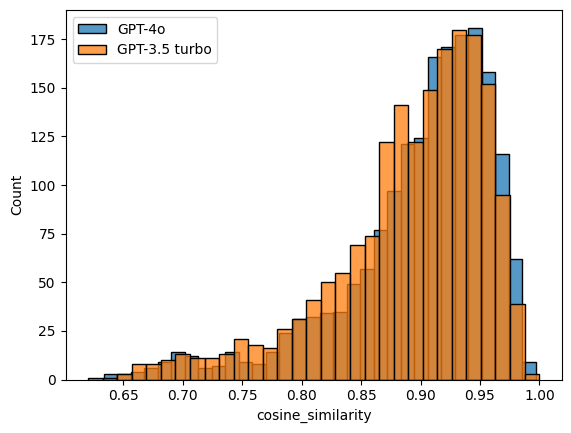

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_gpt4o['cosine_similarity'], label="GPT-4o")
sns.histplot(df_gpt35turbo['cosine_similarity'], label="GPT-3.5 turbo")
plt.legend()
plt.show()